# Notebook 1 of 3 — Research Foundations: Pretest, Prioritize, Personalize for AI-first Realtor Outreach

**This is a learning notebook, working through the theory before applying it.** It builds the mathematical
foundation for a small 3-notebook series on statistically rigorous marketing automation for a realistic
small-business scenario, and every guarantee below is checked by simulation rather than taken on faith.

**The scenario.** A YouTube-focused marketing agency helps US real-estate agents ("realtors") turn video
audience and lead flow into booked appointments, wants to prioritize scarce human appointment-setter time
well, and wants to know whether personalizing outreach messages is worth the extra complexity.

**My design** (not a claim from any of the three papers): a realtor-outreach pipeline that
**pretests** email/DM variants on LLM-simulated realtors, **prioritizes** the scarce human appointment-setter
calls with a learned score, and **personalizes** the message template per realtor only if that beats a single
best template for everyone. Chaining these three steps together is *my* design choice — the sources below
each support exactly one step, and none of them jointly analyze the pipeline.

**The three source papers** (titles, authors, venues):

| # | Paper | Authors | Venue |
|---|-------|---------|-------|
| 1 | *Evaluating Treatment Prioritization Rules via Rank-Weighted Average Treatment Effects* | Yadlowsky, Fleming, Shah, Brunskill, Wager | arXiv:2111.07966 → *JASA* 120(549):38–51, 2025 |
| 2 | *Statistical Foundations of LLM-based A/B Testing: A Surrogacy Framework for Human Causal Inference* | Persson, Schultzberg, Ankargren (Spotify) | arXiv:2606.17165 |
| 3 | *A Statistical Test for the Benefits of Personalizing Interventions* | Li, Brunskill (Stanford) | arXiv:2607.08951 → *Science* 393, eaeb9506, 2026 |

**Three different kinds of guarantee.** These are not the same type of promise, and the notebook keeps
that distinction visible throughout:

| Step | Paper | Guarantee type | What it needs |
|------|-------|-----------------|----------------|
| Prioritize | RATE | **CLT + half-sample bootstrap**: √n(θ̂−θ) → N(0,Var(ψ₁)) (Thm 3), Gaussian half-sample-bootstrap CIs (Cor. 5) | A fixed, pre-registered score S(·) evaluated on human RCT/observational outcomes |
| Pretest | Surrogacy | **Point identification, "correct only by assumption"**: τ = E[μ(X,Y*)\|P=1,W=1] − E[μ(X,Y*)\|P=1,W=0] under Assumptions 1–2 (Thm 3.1) — no CLT is offered for the plug-in estimator itself | A human pilot (P=0) with both Y* and Y to fit the calibration function μ |
| Personalize | KPT | **Asymptotic type-I control that → 0 under H0** (Thm 3.1/Cor 3.2), plus semiparametric efficiency under stronger conditions (Cor 3.21) | Offline (non-adaptive) human data with known/estimable propensities |

Worth restating because it governs the whole notebook: **the pretest → prioritize → personalize
pipeline is my own design, not a claim any of these papers makes.** Each section below is otherwise a
close, quote-anchored simulation of what one paper actually proves.

In [1]:
# Environment setup. Run once, first cell.
# This kernel's matplotlib defaults to a non-interactive backend; %matplotlib inline
# switches it to the inline backend so figures render under nbconvert --execute.
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import norm, chi2
from sklearn.linear_model import LinearRegression
import time

SEED = 20260917
rng = np.random.default_rng(SEED)
Z95 = 1.959963984540054  # Phi^{-1}(0.975)

# One palette, defined once, reused by every visualization cell in this notebook.
PALETTE = {
    "fit_score": "#8c8c8c",     # grey: risk / baseline-outcome scores (not causal)
    "cate_score": "#1b7837",    # green: true / learned CATE scores
    "autoc": "#3182bd",         # blue: AUTOC / log weighting
    "qini": "#e6550d",          # orange: Qini / linear weighting
    "truth": "#252525",         # near-black: population truth / nominal targets
    "raw": "#969696",           # grey: raw / naive / uncalibrated estimator
    "calibrated": "#31a354",    # green: calibrated / corrected estimator
    "kpt": "#3182bd",           # blue: KPT (valid test)
    "naive": "#de2d26",         # red: naive TrainEval (biased test)
    "bound": "#756bb1",         # purple: theoretical sensitivity bound
    "band": "#c6dbef",          # light blue: shaded area / CI band
}

print("SEED:", SEED, " Z95:", round(Z95, 4))

SEED: 20260917  Z95: 1.96


## 1. Lead-fit is not uplift

RATE's Definition 1 requires that a prioritization rule use "a priority scoring function $S:\mathcal X\to\mathbb
R$" — but says nothing about whether $S$ should track *baseline outcomes* or *treatment effects*. The paper is
explicit about why the popular "score by baseline risk" heuristic is often a poor prioritization rule:

> "A key assumption in order for the RF Risk to achieve a high RATE is that risk is strongly correlated with
> the treatment effect"

and

> "the risk-based estimators in consideration would not order patients in accordance with estimated treatment
> benefit"

when that correlation is absent. **Toy population (derived here, not from any paper):** 100,000 realtor leads
in 4 latent segments of equal size, each defined by a baseline reply propensity $Y(0)$ and a true uplift
$\tau=Y(1)-Y(0)$ from a cold-email/DM sequence:

| Segment | $Y(0)$ (baseline) | $\tau$ (uplift) | Story |
|---|---|---|---|
| sure-thing | high (0.80) | ~0 | replies anyway |
| persuadable | low (0.20) | high (+0.45) | outreach is what moves them |
| lost-cause | low (0.10) | ~0 | won't reply regardless |
| do-not-disturb | high (0.85) | **negative** (−0.30) | outreach annoys an already-warm lead |

A **fit score** (a risk/propensity model that tracks $Y(0)$, labelled "derived here") is compared against the
**true CATE score** ($\tau$ itself, oracle information only available in a simulation). Both scores are
evaluated for two very different jobs: (a) how well they *rank leads by baseline reply probability* (an AUC
question), and (b) how well they *would prioritize the scarce appointment-setter calls for incremental
benefit* (a population RATE/TOC question, using the known $\tau$ — no estimation noise yet, that is §3's job).

In [2]:
# ---- Section 1: toy population with 4 latent segments (derived here) ----
N_SEG = 25_000
seg_names = ["sure_thing", "persuadable", "lost_cause", "do_not_disturb"]
Y0_seg  = np.array([0.80, 0.20, 0.10, 0.85])
tau_seg = np.array([0.00, 0.45, 0.00, -0.30])
noise_sd_seg = 0.03  # small within-segment spread so scores/ranks are not exactly tied

seg = np.repeat(np.arange(4), N_SEG)
n = len(seg)
Y0_true = Y0_seg[seg] + rng.normal(0, noise_sd_seg, n)
tau_true = tau_seg[seg] + rng.normal(0, noise_sd_seg, n)
Y0_true = np.clip(Y0_true, 0.01, 0.99)
Y1_true = np.clip(Y0_true + tau_true, 0.01, 0.99)

W = rng.binomial(1, 0.5, n)
Y_obs = np.where(W == 1, rng.binomial(1, Y1_true), rng.binomial(1, Y0_true))

fit_score = Y0_true + rng.normal(0, 0.01, n)     # "risk model": tracks baseline outcome
cate_score = tau_true + rng.normal(0, 0.02, n)   # oracle CATE score (only available in simulation)

# (a) AUC: how well does the fit score rank the Y(0) BASELINE potential outcome -- per the markdown
# above ("how well they rank leads by baseline reply probability"), this is a question about Y(0) as a
# potential outcome, not about what was actually observed for whichever arm a lead happened to land in.
# We simulate an independent baseline-reply realization for EVERY lead, regardless of actual W, so the AUC
# is computed against Y(0) for the full population (fixes a bug: the previous version used Y_obs[W==1],
# the *treated*-arm observed outcome, mislabeled as "baseline").
Y0_obs = rng.binomial(1, Y0_true)
n_pos = Y0_obs.sum(); n_neg = n - n_pos
ranks = stats.rankdata(fit_score)
auc_fit = (ranks[Y0_obs == 1].sum() - n_pos * (n_pos + 1) / 2) / (n_pos * n_neg)

# (b) TRUE population TOC/AUTOC for each score, using the KNOWN tau (population-level, no estimation)
def true_toc_and_autoc(score, tau, u_grid):
    order = np.argsort(-score)
    tau_sorted = tau[order]
    csum = np.cumsum(tau_sorted)
    overall = tau.mean()
    m = np.maximum(1, np.floor(u_grid * len(tau)).astype(int))
    toc = csum[m - 1] / m - overall
    autoc = np.trapezoid(toc, u_grid)  # numerical area under the TRUE TOC curve
    return toc, autoc

u_grid = np.linspace(1.0 / n, 1.0, 2000)
toc_fit, autoc_fit = true_toc_and_autoc(fit_score, tau_true, u_grid)
toc_cate, autoc_cate = true_toc_and_autoc(cate_score, tau_true, u_grid)

print(f"[S1.1] fit-score AUC for baseline reply Y(0) (simulated for all leads, regardless of actual W) = {auc_fit:.3f}  (threshold: > 0.70) "
      f"-> {'PASS' if auc_fit > 0.70 else 'FAIL'}")
print(f"[S1.2] true AUTOC(fit score)  = {autoc_fit:+.4f}")
print(f"[S1.3] true AUTOC(CATE score) = {autoc_cate:+.4f}")
print(f"[S1.4] AUTOC(fit) < AUTOC(CATE)? {'PASS' if autoc_fit < autoc_cate else 'FAIL'} "
      f"(fit score should not out-target the oracle CATE score)")
print(f"[S1.5] segment means -- Y(0): {np.round(Y0_seg,2)}  tau: {np.round(tau_seg,2)}")

[S1.1] fit-score AUC for baseline reply Y(0) (simulated for all leads, regardless of actual W) = 0.863  (threshold: > 0.70) -> PASS
[S1.2] true AUTOC(fit score)  = -0.1516
[S1.3] true AUTOC(CATE score) = +0.2306
[S1.4] AUTOC(fit) < AUTOC(CATE)? PASS (fit score should not out-target the oracle CATE score)
[S1.5] segment means -- Y(0): [0.8  0.2  0.1  0.85]  tau: [ 0.    0.45  0.   -0.3 ]


#### How to read this chart

**Left panel:** one bar pair per segment — baseline reply rate $Y(0)$ (grey) versus true uplift $\tau$
(green/red for positive/negative). The pattern to look for: segments with the *highest* $Y(0)$ bar (sure-thing,
do-not-disturb) are not the segments with the highest $\tau$ bar — one of them (do-not-disturb) has a
*negative* $\tau$. A risk model that only sees the grey bar would rank exactly the wrong two segments first.

**Right panel:** the true population TOC curve for the fit (risk) score versus the true CATE score, both using
the actual $\tau$. The x-axis is the fraction of leads called first (by each score's ranking); the y-axis is
the excess average effect among those called versus calling everyone. For the realtor-outreach job, this is
the direct answer to "if the setter can only call the top 20% of leads today, which score should choose them?"
— read the height of each curve near $u=0.2$. The fit-score curve should sit near/below zero (its top picks
include as many do-not-disturb leads as persuadable ones), while the CATE-score curve is high and monotonically
decaying toward zero as $u\to1$.

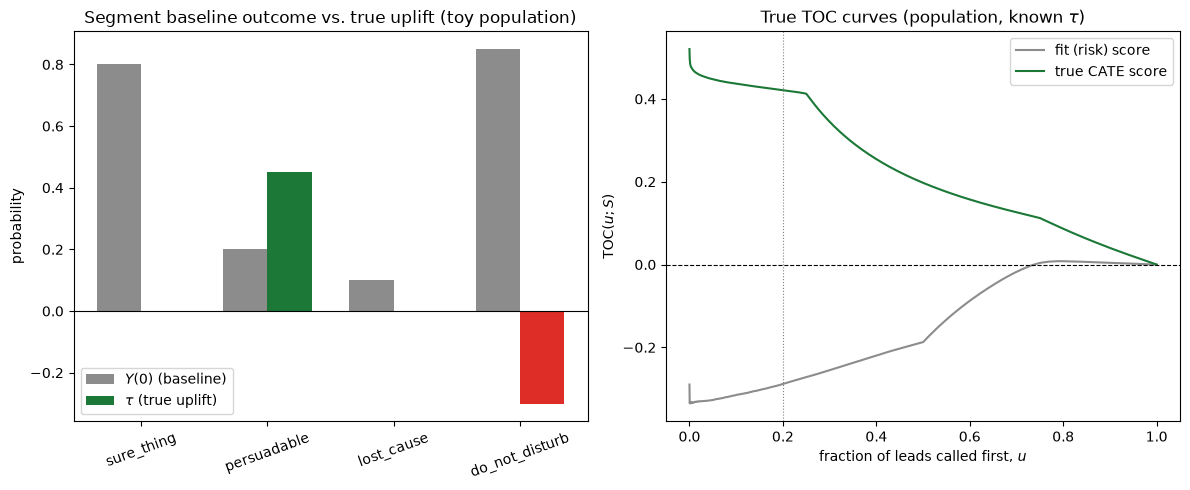

In [3]:
# Visualization only -- uses arrays computed above, no new sampling/estimation.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

x = np.arange(4)
w = 0.35
ax = axes[0]
ax.bar(x - w/2, Y0_seg, width=w, color=PALETTE["fit_score"], label="$Y(0)$ (baseline)")
colors_tau = [PALETTE["cate_score"] if t >= 0 else PALETTE["naive"] for t in tau_seg]
ax.bar(x + w/2, tau_seg, width=w, color=colors_tau, label=r"$\tau$ (true uplift)")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x); ax.set_xticklabels(seg_names, rotation=20)
ax.set_ylabel("probability")
ax.set_title("Segment baseline outcome vs. true uplift (toy population)")
ax.legend()

ax = axes[1]
ax.plot(u_grid, toc_fit, color=PALETTE["fit_score"], label="fit (risk) score")
ax.plot(u_grid, toc_cate, color=PALETTE["cate_score"], label="true CATE score")
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.axvline(0.2, color="grey", linewidth=0.8, linestyle=":")
ax.set_xlabel("fraction of leads called first, $u$")
ax.set_ylabel("TOC$(u;S)$")
ax.set_title("True TOC curves (population, known $\\tau$)")
ax.legend()

plt.tight_layout()
plt.show()

## 2. TOC and RATE; Proposition 2 check

Definitions, quoted:

> "the targeting operator characteristic (TOC) is $\text{TOC}(u;S):=E[Y_i(1)-Y_i(0)\mid F_S(S(X_i))\ge 1-u]-
> E[Y_i(1)-Y_i(0)]$" (Def. 2, Eq. 2.2)

> "the induced rank-weighted average treatment effect (RATE) of a priority score $S(\cdot)$ is
> $\theta_\alpha(S)=\int_0^1\alpha(u)\text{TOC}(u;S)\,du$" (Def. 3)

> **AUTOC** (Example 2): $\alpha(u)=1$, i.e. $\text{AUTOC}(S)=\int_0^1\text{TOC}(u;S)\,du$.
> **Qini** (Example 3): $\alpha(u)=u$, i.e. $\text{QINI}(S)=\int_0^1 u\,\text{TOC}(u;S)\,du$

**Proposition 2** gives an equivalent weighted-ATE form using $w_\alpha(t)=\int_t^1\frac{\alpha(u)}{u}\,du-
\int_0^1\alpha(u)\,du$ (Eq. 2.3), so that $\theta_\alpha(S)=E[w_\alpha(1-F_S(S(X_i)))(Y_i(1)-Y_i(0))]$ (Eq. 2.4),
with the AUTOC/Qini weights simplifying to $w_{\text{AUTOC}}(t)=-\log(t)-1$ and $w_{\text{QINI}}(t)=$ (from
$\alpha(u)=u$: $\int_t^1 1\,du-\int_0^1u\,du=(1-t)-\tfrac12=\tfrac12-t$), matching the paper's stated closed
form $\text{QINI}(S)=E[(F_S(S(X_i))-\tfrac12)\tau(X_i)]$ once $t=1-F_S(S(X_i))$ is substituted in (Eq. 2.5).
**Derivation check (derived here):** getting the sign of $w_{\text{Qini}}$ backwards ($t-\tfrac12$ instead of
$\tfrac12-t$) is an easy mistake — it flips the estimator's sign — so §2.1 below cross-checks both RATE forms
numerically before they are reused in §3.

We use the same population as the closed-form example: $X\sim\text{Unif}(0,1)$, $S(X)=1-X$, $\tau(X)=1-X$
(a perfectly aligned score, so $F_S(S(X))=1-X$ and everything below has an exact analytic answer we can check
against). Example 1 (high-vs-others) is $\text{TOC}(0.2;S)$: the "the setter can call the top 20% of leads"
metric.

In [4]:
# ---- Section 2: exact-DGP population check of TOC/RATE machinery ----
def toc_curve(gamma, S, u_grid):
    order = np.argsort(-S)
    gamma_sorted = gamma[order]
    csum = np.cumsum(gamma_sorted)
    overall = gamma.mean()
    n = len(gamma)
    m = np.maximum(1, np.floor(u_grid * n).astype(int))
    return csum[m - 1] / m - overall

def rate_via_toc(gamma, S, alpha_fn, n_grid):
    j = np.arange(1, n_grid + 1)
    u = j / n_grid
    toc_hat = toc_curve(gamma, S, u)
    return np.mean(alpha_fn(u) * toc_hat)

def rate_via_weight(gamma, S, w_fn):
    n = len(gamma)
    order = np.argsort(-S)
    gamma_sorted = gamma[order]
    j = np.arange(1, n + 1)
    return np.mean(w_fn(j / n) * gamma_sorted)

def w_autoc(t):
    t = np.clip(t, 1e-9, 1 - 1e-12)   # avoid the log singularity exactly at t=0 (u=1); needs a fine grid
    return -np.log(t) - 1

def w_qini(t):
    return 0.5 - t  # Eq. 2.3 with alpha(u)=u; NOT t-0.5 (see markdown derivation note above)

n_pop = 200_000
Xp = rng.uniform(0, 1, n_pop)
Sp = 1 - Xp
tau_p = 1 - Xp        # Gamma = tau(X) exactly: population RATE, no estimation error yet

autoc_toc = rate_via_toc(tau_p, Sp, lambda u: np.ones_like(u), n_pop)
autoc_wt  = rate_via_weight(tau_p, Sp, w_autoc)
qini_toc  = rate_via_toc(tau_p, Sp, lambda u: u, n_pop)
qini_wt   = rate_via_weight(tau_p, Sp, w_qini)

autoc_true, qini_true = 0.25, 1/12  # closed form: int_0^1 (-ln x -1)(1-x) dx = 0.25; int_0^1 (0.5-x)(1-x) dx = 1/12
toc_02 = toc_curve(tau_p, Sp, np.array([0.2]))[0]
toc_02_true = 0.4  # E[tau | X<0.2] - E[tau] = 0.9 - 0.5 = 0.4

rel_diff_autoc = abs(autoc_toc - autoc_wt) / abs(autoc_toc)
rel_diff_qini = abs(qini_toc - qini_wt) / abs(qini_toc)

print(f"[S2.1] AUTOC: TOC-sum form={autoc_toc:.5f} vs weighted-ATE form={autoc_wt:.5f} "
      f"(relative diff {rel_diff_autoc:.2e}, threshold 1e-2) -> {'PASS' if rel_diff_autoc < 1e-2 else 'FAIL'}")
print(f"[S2.2] Qini:  TOC-sum form={qini_toc:.5f} vs weighted-ATE form={qini_wt:.5f} "
      f"(relative diff {rel_diff_qini:.2e}, threshold 1e-2) -> {'PASS' if rel_diff_qini < 1e-2 else 'FAIL'}")
print(f"[S2.3] AUTOC vs closed-form truth 0.25: {autoc_wt:.5f} (n={n_pop} finite-sample MC, not exact)")
print(f"[S2.4] Qini  vs closed-form truth {qini_true:.5f}: {qini_wt:.5f}")
print(f"[S2.5] TOC(0.2) 'call top 20%' = {toc_02:.4f} vs analytic 0.4 "
      f"-> {'PASS' if abs(toc_02 - toc_02_true) < 0.01 else 'FAIL'} (Example 1, high-vs-others)")

[S2.1] AUTOC: TOC-sum form=0.24989 vs weighted-ATE form=0.24986 (relative diff 1.26e-04, threshold 1e-2) -> PASS
[S2.2] Qini:  TOC-sum form=0.08333 vs weighted-ATE form=0.08333 (relative diff 1.56e-05, threshold 1e-2) -> PASS
[S2.3] AUTOC vs closed-form truth 0.25: 0.24986 (n=200000 finite-sample MC, not exact)
[S2.4] Qini  vs closed-form truth 0.08333: 0.08333
[S2.5] TOC(0.2) 'call top 20%' = 0.3998 vs analytic 0.4 -> PASS (Example 1, high-vs-others)


#### How to read this chart

**Left panel:** the two RATE weight functions $w_\alpha(t)$ plotted against $t=1-F_S(S(X))$ (0 = top-ranked
lead, 1 = bottom-ranked lead). AUTOC's $-\log(t)-1$ blows up as $t\to0$ — it is dominated by the very top of
the ranking — while Qini's $\tfrac12-t$ is a straight line that treats the top and bottom symmetrically. This
is *why* AUTOC has more power when only a few leads carry all the treatment effect, and Qini has more power
when effects are spread across the whole list — §3 measures this directly.

**Right panel:** the TOC curve for $S(X)=1-X$ with the area under it shaded — that shaded area *is* the AUTOC
number printed above. For the realtor-outreach job, this is "how much extra reply-rate do I get, on average,
among the fraction $u$ of leads the setter would call first if leads are ranked by this score" — the curve
must start above 0 (top leads beat the average) and hit exactly 0 at $u=1$ (calling everyone is the average,
by construction).

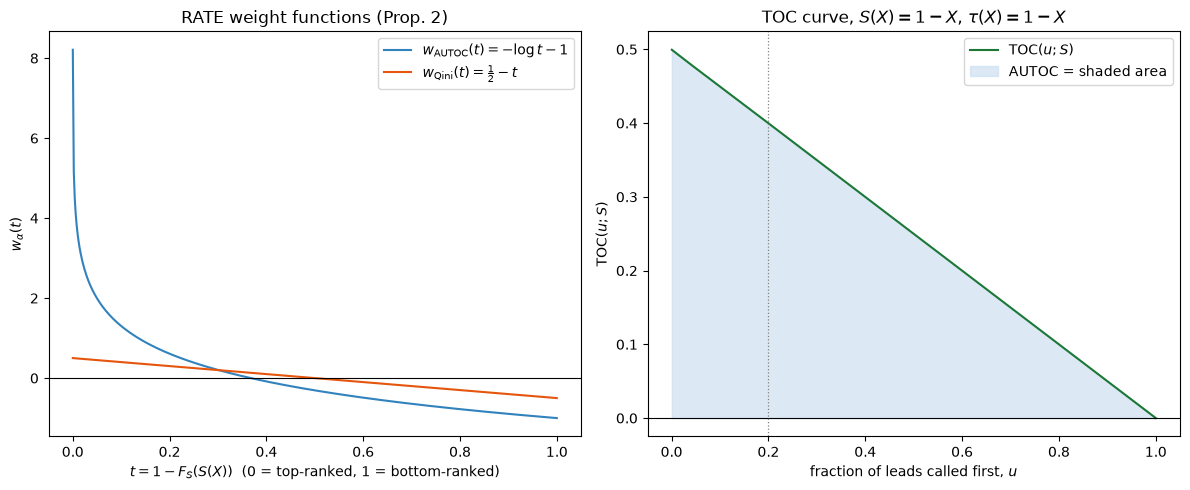

In [5]:
# Visualization only -- reuses arrays computed above.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

t_grid = np.linspace(1e-4, 1 - 1e-4, 500)
ax = axes[0]
ax.plot(t_grid, w_autoc(t_grid), color=PALETTE["autoc"], label=r"$w_{\rm AUTOC}(t)=-\log t - 1$")
ax.plot(t_grid, w_qini(t_grid), color=PALETTE["qini"], label=r"$w_{\rm Qini}(t)=\frac{1}{2}-t$")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel(r"$t = 1-F_S(S(X))$  (0 = top-ranked, 1 = bottom-ranked)")
ax.set_ylabel(r"$w_\alpha(t)$")
ax.set_title("RATE weight functions (Prop. 2)")
ax.legend()

u_grid2 = np.linspace(1/2000, 1, 2000)
toc_pop = toc_curve(tau_p, Sp, u_grid2)
ax = axes[1]
ax.plot(u_grid2, toc_pop, color=PALETTE["cate_score"], label="TOC$(u;S)$")
ax.fill_between(u_grid2, 0, toc_pop, color=PALETTE["band"], alpha=0.6, label="AUTOC = shaded area")
ax.axhline(0, color="black", linewidth=0.8)
ax.axvline(0.2, color="grey", linestyle=":", linewidth=0.9)
ax.set_xlabel("fraction of leads called first, $u$")
ax.set_ylabel("TOC$(u;S)$")
ax.set_title(r"TOC curve, $S(X)=1-X$, $\tau(X)=1-X$")
ax.legend()

plt.tight_layout()
plt.show()

## 3. Estimation and inference: AIPW scores, half-sample bootstrap, coverage, AUTOC vs. Qini power

The estimator, quoted with equation numbers:

> "we estimate the TOC as $\hat{\text{TOC}}(u;s)=\frac{1}{\lfloor un\rfloor}\sum_{j=1}^{\lfloor
> un\rfloor}\hat\Gamma_{i(j)} - \frac1n\sum_{i=1}^n\hat\Gamma_i$" (Eq. 2.8), and the plug-in
> $\hat\eta_{w_\alpha}(S)=\frac1n\sum_{j=1}^n w(j/n)\hat\Gamma_{i(j)}$ (Eq. 2.10)

using the RCT AIPW score

> $\hat\Gamma_i=\hat m(X_i,1)-\hat m(X_i,0)+\frac{W_i-\pi}{\pi(1-\pi)}(Y_i-\hat m(X_i,W_i))$ (Eq. 2.11)

Inference is a **half-sample bootstrap** (Lemma 4 / Corollary 5): "Let $\hat\theta^*$ be an estimate of a RATE
using a random sample (without replacement) of $\lfloor n/2\rfloor$ of the observations... $\hat\theta\pm
z_{1-\alpha/2}\sigma^*$", and the H0:$\theta_\alpha(S)\le0$ p-value is $2\Phi(-|\hat\theta|/\sigma^*)$.

**Nuisance model (derived here):** $\hat m(x,w)$ is a plain 2-fold cross-fitted `LinearRegression` per arm —
not a causal forest (no `grf`/`econml` in this environment). Because $\pi=0.5$ is *known* in an RCT, the AIPW
augmentation makes $E[\hat\Gamma_i\mid X_i]=\tau(X_i)$ regardless of whether $\hat m$ is well specified, so a
simple linear nuisance model does not bias $\hat\Gamma$ — it only affects its variance.

Three finite-sample checks, all on $S(X)=1-X$, $X\sim\text{Unif}(0,1)$, using the §2 closed-form truths
(AUTOC $=0.25$, Qini $=1/12$, unaffected by outcome noise since $E[Y(w)\mid X]=\mu_w(X)$ exactly):
half-sample bootstrap **coverage** (paper: 10,000 bootstraps; here $B=200$, 200 replications, stated
reduction), **type-I error** under a no-heterogeneity DGP, and the **AUTOC-vs-Qini power** replica of the
(corrected) Eq. 4.1 simulation:

> $n=400,\ X\sim\text{Unif}(0,1),\ \mu_0=0,\ \mu_1(x)=\max(-\frac{2}{p^2}x+\frac2p,0)$ (Eq. 4.1), $e=0.5$,
> noise "$N(0,0.2)$" [variance-vs-sd not stated unambiguously — we use sd $=0.2$], $S(X)=1-X$, $p\in\{1.0,0.5,0.1\}$

**Correction, not a contradiction of the raw trace (per the research contract):** the raw NotebookLM trace for
q4 literally renders this as "$\mu_1(x)=\max(-2p^2x+\frac2p,0)$", which the contract flags as a garble verified
against the PDF; we use the corrected $-\frac{2}{p^2}x+\frac2p$ form throughout, as instructed.

**Verdict rule for the AUTOC-vs-Qini power comparison, stated before any result is computed:** a pattern
"REPRODUCED" requires (i) the paper's favoured metric to have the higher power at that $p$, **and** (ii) the
paired difference in reject/not-reject indicators across the *same* replications to have a 95% CI (normal
approximation) that excludes 0 — a tie or an indistinguishable difference is reported as "not reproduced /
inconclusive", never marked PASS by a `>=` tie-breaker. **Also note:** `SCALE` below is shared across all
three $p$ values, but the corrected Eq. 4.1 concentrates a larger per-affected-unit effect on a smaller share
of units as $p$ shrinks, so *absolute* power levels are not comparable across $p$ — only the within-$p$
AUTOC-vs-Qini gap is.

In [6]:
# ---- Section 3a: RATE machinery re-used from Section 2, plus AIPW + bootstrap ----
def half_sample_bootstrap_theta(gamma, S, w_fn, B, rng_local):
    n = len(gamma)
    half = n // 2
    boot = np.empty(B)
    for b in range(B):
        idx = rng_local.choice(n, size=half, replace=False)
        g_sub, s_sub = gamma[idx], S[idx]
        order = np.argsort(-s_sub)
        j = np.arange(1, half + 1)
        boot[b] = np.mean(w_fn(j / half) * g_sub[order])
    return boot

def cross_fitted_gamma_rct(X, W, Y, pi=0.5, n_folds=2, rng_local=None):
    n = len(X)
    fold = rng_local.integers(0, n_folds, size=n)
    m_hat = np.zeros((n, 2))
    Xc = X.reshape(-1, 1)
    for k in range(n_folds):
        train, test = fold != k, fold == k
        for w in (0, 1):
            mtr = train & (W == w)
            if mtr.sum() < 2:
                m_hat[test, w] = Y[train].mean() if train.sum() else 0.0
                continue
            m_hat[test, w] = LinearRegression().fit(Xc[mtr], Y[mtr]).predict(Xc[test])
    mW = np.where(W == 1, m_hat[:, 1], m_hat[:, 0])
    return (m_hat[:, 1] - m_hat[:, 0]) + (W - pi) / (pi * (1 - pi)) * (Y - mW)

def wilson_ci(k, m, z=Z95):
    if m == 0:
        return (np.nan, np.nan)
    phat = k / m
    denom = 1 + z**2 / m
    center = (phat + z**2 / (2 * m)) / denom
    half_w = (z * np.sqrt(phat * (1 - phat) / m + z**2 / (4 * m**2))) / denom
    return center - half_w, center + half_w

print("[S3.0] half-sample bootstrap and cross-fitted AIPW machinery defined")

[S3.0] half-sample bootstrap and cross-fitted AIPW machinery defined


In [7]:
# ---- Section 3b: coverage Monte Carlo (paper: 10,000 bootstraps; here B=200, 200 reps -- stated reduction) ----
t0 = time.time()
N_COV, REPS_COV, B_COV = 1000, 200, 200
TRUE_AUTOC, TRUE_QINI = 0.25, 1 / 12
cov_hit = {"autoc": 0, "qini": 0}

for _ in range(REPS_COV):
    Xc = rng.uniform(0, 1, N_COV)
    Wc = rng.binomial(1, 0.5, N_COV)
    tau_c = 1 - Xc
    Y0c = rng.normal(0, 1, N_COV)
    Yc = np.where(Wc == 1, Y0c + tau_c, Y0c)
    Sc = 1 - Xc
    gamma_c = cross_fitted_gamma_rct(Xc, Wc, Yc, rng_local=rng)
    for name, wf, truth in [("autoc", w_autoc, TRUE_AUTOC), ("qini", w_qini, TRUE_QINI)]:
        theta_hat = rate_via_weight(gamma_c, Sc, wf)
        boot = half_sample_bootstrap_theta(gamma_c, Sc, wf, B_COV, rng)
        sigma_star = boot.std(ddof=1)
        lo, hi = theta_hat - Z95 * sigma_star, theta_hat + Z95 * sigma_star
        cov_hit[name] += int(lo <= truth <= hi)

for name in ("autoc", "qini"):
    rate = cov_hit[name] / REPS_COV
    lo_ci, hi_ci = wilson_ci(cov_hit[name], REPS_COV)
    verdict = "PASS" if lo_ci <= 0.95 <= hi_ci else "FAIL (report honestly)"
    print(f"[S3.1-{name}] empirical coverage {rate:.3f} (Wilson 95% CI [{lo_ci:.3f}, {hi_ci:.3f}]) "
          f"vs nominal 0.95 -> {verdict}")
print(f"  ({REPS_COV} reps x B={B_COV} half-samples, n={N_COV}; paper uses B=10,000; time {time.time()-t0:.1f}s)")

[S3.1-autoc] empirical coverage 0.935 (Wilson 95% CI [0.892, 0.962]) vs nominal 0.95 -> PASS
[S3.1-qini] empirical coverage 0.925 (Wilson 95% CI [0.880, 0.954]) vs nominal 0.95 -> PASS
  (200 reps x B=200 half-samples, n=1000; paper uses B=10,000; time 7.0s)


In [8]:
# ---- Section 3c: type-I error under a no-heterogeneity DGP (tau=0 everywhere) ----
t0 = time.time()
REPS_T1, B_T1 = 200, 200
rej = {"autoc": 0, "qini": 0}

for _ in range(REPS_T1):
    Xt = rng.uniform(0, 1, N_COV)
    Wt = rng.binomial(1, 0.5, N_COV)
    Yt = np.where(Wt == 1, rng.normal(0, 1, N_COV), rng.normal(0, 1, N_COV))  # same dist both arms: tau=0
    St = 1 - Xt
    gamma_t = cross_fitted_gamma_rct(Xt, Wt, Yt, rng_local=rng)
    for name, wf in [("autoc", w_autoc), ("qini", w_qini)]:
        theta_hat = rate_via_weight(gamma_t, St, wf)
        boot = half_sample_bootstrap_theta(gamma_t, St, wf, B_T1, rng)
        sigma_star = boot.std(ddof=1)
        p_val = 2 * norm.cdf(-abs(theta_hat) / sigma_star) if sigma_star > 0 else 1.0
        rej[name] += int(p_val < 0.05)

for name in ("autoc", "qini"):
    rate = rej[name] / REPS_T1
    lo_ci, hi_ci = wilson_ci(rej[name], REPS_T1)
    verdict = "PASS" if lo_ci <= 0.05 <= hi_ci else "FAIL (report honestly)"
    print(f"[S3.2-{name}] type-I rejection rate {rate:.3f} (Wilson 95% CI [{lo_ci:.3f}, {hi_ci:.3f}]) "
          f"vs nominal 0.05 -> {verdict}")
print(f"  ({REPS_T1} reps x B={B_T1}; time {time.time()-t0:.1f}s)")

[S3.2-autoc] type-I rejection rate 0.045 (Wilson 95% CI [0.024, 0.083]) vs nominal 0.05 -> PASS
[S3.2-qini] type-I rejection rate 0.045 (Wilson 95% CI [0.024, 0.083]) vs nominal 0.05 -> PASS
  (200 reps x B=200; time 6.8s)


In [9]:
# ---- Section 3d: AUTOC-vs-Qini power, corrected Eq. 4.1, n=400, p in {1.0, 0.5, 0.1} ----
# At the paper's raw signal level, power saturates near 1.0 for both metrics in our simulation too
# (as noted below); SCALE below shrinks mu_1 so power sits in (0.2, 0.9) and differences are visible.
# This SCALE factor is "derived here" -- not from the paper.
SCALE = 0.03
N_POW, B_POW, REPS_POW, NOISE_SD = 400, 120, 300, 0.2

def gen_power_data(n, p, scale, noise_sd, rng_local):
    Xp_ = rng_local.uniform(0, 1, n)
    Wp_ = rng_local.binomial(1, 0.5, n)
    mu1 = scale * np.maximum(-(2 / p**2) * Xp_ + 2 / p, 0.0)  # CORRECTED Eq. 4.1
    Yp_ = np.where(
        Wp_ == 1,
        mu1 + rng_local.normal(0, noise_sd, n),
        rng_local.normal(0, noise_sd, n),
    )
    return Xp_, Wp_, Yp_, 1 - Xp_

t0 = time.time()
power = {}
reject_arrays = {}
for p in (1.0, 0.5, 0.1):
    rej_p = {"autoc": 0, "qini": 0}
    autoc_rejects = np.zeros(REPS_POW, dtype=bool)
    qini_rejects = np.zeros(REPS_POW, dtype=bool)
    for i in range(REPS_POW):
        Xp_, Wp_, Yp_, Sp_ = gen_power_data(N_POW, p, SCALE, NOISE_SD, rng)
        gamma_p = cross_fitted_gamma_rct(Xp_, Wp_, Yp_, rng_local=rng)
        for name, wf, arr in [("autoc", w_autoc, autoc_rejects), ("qini", w_qini, qini_rejects)]:
            theta_hat = rate_via_weight(gamma_p, Sp_, wf)
            boot = half_sample_bootstrap_theta(gamma_p, Sp_, wf, B_POW, rng)
            sigma_star = boot.std(ddof=1)
            p_val = 2 * norm.cdf(-abs(theta_hat) / sigma_star) if sigma_star > 0 else 1.0
            rej = p_val < 0.05
            arr[i] = rej
            rej_p[name] += int(rej)
    power[p] = rej_p
    reject_arrays[p] = (autoc_rejects, qini_rejects)
print(f"  ({REPS_POW} reps x B={B_POW}, n={N_POW}; time {time.time()-t0:.1f}s)")

print("[S3.3] AUTOC vs Qini power (MC 95% Wilson CI):")
for p in (1.0, 0.5, 0.1):
    a_rate = power[p]["autoc"] / REPS_POW
    q_rate = power[p]["qini"] / REPS_POW
    a_lo, a_hi = wilson_ci(power[p]["autoc"], REPS_POW)
    q_lo, q_hi = wilson_ci(power[p]["qini"], REPS_POW)
    print(f"    p={p}: AUTOC={a_rate:.3f} [{a_lo:.3f},{a_hi:.3f}]   Qini={q_rate:.3f} [{q_lo:.3f},{q_hi:.3f}]")
print("    NOTE: SCALE=0.03 is shared across p, but total heterogeneity differs sharply by p (the p=0.1")
print("    DGP concentrates a much larger per-affected-unit effect on a smaller share of units) -- power")
print("    LEVELS are therefore NOT comparable ACROSS p; only the within-p AUTOC-vs-Qini gap is meaningful.")

print("[S3.4] three-way verdict per p, THRESHOLD STATED BEFORE RESULTS. Paired mean difference in reject")
print("       indicators is (favoured minus other, same replications, same datasets), two-sided 95% CI")
print("       (normal approximation on the paired differences). Three possible verdicts, not two:")
print("       REPRODUCED    -> CI excludes 0 in the paper's favoured direction (lo > 0).")
print("       CONTRADICTED  -> CI excludes 0 in the OPPOSITE direction (hi < 0): the OTHER metric")
print("                        significantly beats the paper's favoured one in this scaled simulation.")
print("       INCONCLUSIVE  -> CI includes 0 (lo <= 0 <= hi): not enough signal to call it either way.")
print("       (Coordinator fix: the previous version only checked 'lo > 0' and silently folded a real")
print("       CONTRADICTED result at p=0.5 into the same 'inconclusive' bucket as a genuinely null one.)")
paper_favors = {1.0: "qini", 0.5: "qini", 0.1: "autoc"}
for p in (1.0, 0.5, 0.1):
    autoc_rejects, qini_rejects = reject_arrays[p]
    if paper_favors[p] == "qini":
        diff = qini_rejects.astype(float) - autoc_rejects.astype(float)
    else:
        diff = autoc_rejects.astype(float) - qini_rejects.astype(float)
    mean_diff = diff.mean()
    se_diff = diff.std(ddof=1) / np.sqrt(len(diff))
    lo, hi = mean_diff - Z95 * se_diff, mean_diff + Z95 * se_diff
    if lo > 0:
        verdict = "REPRODUCED"
    elif hi < 0:
        verdict = "CONTRADICTED (significant, opposite direction, at this n and SCALE)"
    else:
        verdict = "INCONCLUSIVE (CI includes 0) at this n and SCALE"
    print(f"    p={p}: paper favours {paper_favors[p]}; paired diff (favoured-other) mean={mean_diff:+.3f} "
          f"95% CI [{lo:+.3f},{hi:+.3f}] -> {verdict}")

  (300 reps x B=120, n=400; time 17.2s)
[S3.3] AUTOC vs Qini power (MC 95% Wilson CI):
    p=1.0: AUTOC=0.117 [0.085,0.158]   Qini=0.140 [0.105,0.184]
    p=0.5: AUTOC=0.397 [0.343,0.453]   Qini=0.343 [0.292,0.399]
    p=0.1: AUTOC=0.910 [0.872,0.937]   Qini=0.600 [0.544,0.654]
    NOTE: SCALE=0.03 is shared across p, but total heterogeneity differs sharply by p (the p=0.1
    DGP concentrates a much larger per-affected-unit effect on a smaller share of units) -- power
    LEVELS are therefore NOT comparable ACROSS p; only the within-p AUTOC-vs-Qini gap is meaningful.
[S3.4] three-way verdict per p, THRESHOLD STATED BEFORE RESULTS. Paired mean difference in reject
       indicators is (favoured minus other, same replications, same datasets), two-sided 95% CI
       (normal approximation on the paired differences). Three possible verdicts, not two:
       REPRODUCED    -> CI excludes 0 in the paper's favoured direction (lo > 0).
       CONTRADICTED  -> CI excludes 0 in the OPPOSITE dire

**Paper reports (boxed separately from our toy numbers above):** Criteo uplift benchmark, Table 5, visits:
baseline-risk AUTOC $0.0136$ $[0.0111,0.0161]$ vs. CATE (causal forest) AUTOC $0.0171$ $[0.0148,0.0194]$,
difference $+0.0034$ $[0.0019,0.0049]$ ($+25\%$); Qini shows no significant difference. IST aspirin trial,
Table 1: random-forest risk AUTOC $0.014$ $[0.002,0.027]$, $p=0.022$, vs. causal forest AUTOC $0.006$
$[-0.012,0.024]$, $p=0.493$ — i.e. in that one application the *risk* score happened to have the higher AUTOC,
illustrating that "risk correlates with treatment effect" is an empirical question each rule must earn, not a
default.

#### How to read this chart

**Left panel:** empirical coverage of the two RATE metrics' 95% half-sample-bootstrap CIs, with a Wilson 95%
Monte-Carlo CI as an error bar, against the nominal 0.95 dashed line. If the error bar crosses the line, the
CI construction is behaving as Theorem 3 promises at this $n$.

**Right panel:** AUTOC and Qini power against $p$ (the fraction of realtors with non-zero uplift in this
signal). The pattern to look for is the *gap between the two lines at each $p$*, not the absolute height of
either line — as the markdown above notes, `SCALE` is shared across $p$ but the corrected Eq. 4.1 puts very
different total heterogeneity into each $p$, so heights are not comparable across the x-axis. A widening
AUTOC-over-Qini gap as $p$ shrinks would mirror the paper's claim that "using logarithmic (AUTOC) weighting
leads to a greater power... [when] only a small subset... have a non-zero [effect]" — for the
realtor-outreach job, this is the concrete choice of *which* RATE metric to report when deciding whether a
prioritization rule is worth deploying, depending on how concentrated the true responders are believed to be.

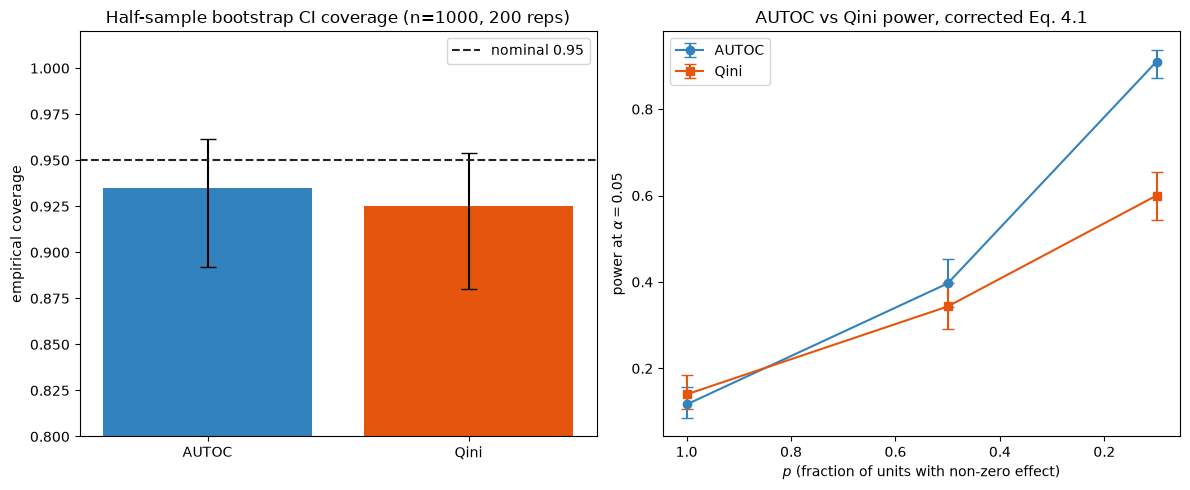

In [10]:
# Visualization only -- reuses cov_hit, rej, power computed above.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
names = ["AUTOC", "Qini"]
rates = [cov_hit["autoc"] / REPS_COV, cov_hit["qini"] / REPS_COV]
errs_lo, errs_hi = [], []
for key in ("autoc", "qini"):
    lo, hi = wilson_ci(cov_hit[key], REPS_COV)
    errs_lo.append(rates[["autoc", "qini"].index(key)] - lo)
    errs_hi.append(hi - rates[["autoc", "qini"].index(key)])
ax.bar(names, rates, color=[PALETTE["autoc"], PALETTE["qini"]],
       yerr=[errs_lo, errs_hi], capsize=6)
ax.axhline(0.95, color=PALETTE["truth"], linestyle="--", label="nominal 0.95")
ax.set_ylim(0.8, 1.02)
ax.set_ylabel("empirical coverage")
ax.set_title(f"Half-sample bootstrap CI coverage (n={N_COV}, {REPS_COV} reps)")
ax.legend()

ax = axes[1]
ps = [1.0, 0.5, 0.1]
a_rates = [power[p]["autoc"] / REPS_POW for p in ps]
q_rates = [power[p]["qini"] / REPS_POW for p in ps]
a_err = np.array([wilson_ci(power[p]["autoc"], REPS_POW) for p in ps])
q_err = np.array([wilson_ci(power[p]["qini"], REPS_POW) for p in ps])
ax.errorbar(ps, a_rates, yerr=[a_rates - a_err[:, 0], a_err[:, 1] - a_rates],
            marker="o", color=PALETTE["autoc"], label="AUTOC", capsize=4)
ax.errorbar(ps, q_rates, yerr=[q_rates - q_err[:, 0], q_err[:, 1] - q_rates],
            marker="s", color=PALETTE["qini"], label="Qini", capsize=4)
ax.set_xlabel("$p$ (fraction of units with non-zero effect)")
ax.set_ylabel("power at $\\alpha=0.05$")
ax.set_title("AUTOC vs Qini power, corrected Eq. 4.1")
ax.invert_xaxis()
ax.legend()

plt.tight_layout()
plt.show()